# Sistema de Recomendação por Similaridade de Usuários

## Objetivo
Este notebook constrói um sistema de recomendação baseado no comportamento de escuta dos usuários.

A abordagem utilizada:
- Processar histórico de consumo
- Criar um score de preferência por gênero
- Representar usuários em um espaço vetorial
- Encontrar usuários similares usando KNN
- Visualizar os grupos com PCA


## Passo 1: Importação das bibliotecas e configuração do ambiente


In [11]:
import requests
import base64
import pandas as pd
from typing import Dict, Any
from dotenv import load_dotenv
load_dotenv()
import os
import json
from typing import Dict, Any

## Passo 2: Carregamento e consolidação dos dados

Nesta etapa, os arquivos JSON do histórico de streaming são lidos e combinados em um único DataFrame.


In [12]:
def folder_to_df_merged(folder_path: str) -> Dict[str, pd.DataFrame]:
    result = {}

    for file in os.listdir(folder_path):
        if not file.endswith(".json"):
            continue

        path = os.path.join(folder_path, file)

        with open(path, encoding="utf-8") as f:
            data: Any = json.load(f)

        if isinstance(data, list) and all(isinstance(i, dict) for i in data):
            df = pd.json_normalize(data)

        elif isinstance(data, dict):
            list_keys = [k for k, v in data.items() if isinstance(v, list)]

            if list_keys:
                main_key = list_keys[0]
                df = pd.json_normalize(
                    data,
                    record_path=main_key,
                    meta=[k for k in data.keys() if k != main_key],
                    errors="ignore"
                )
            else:
                df = pd.DataFrame([data])

        else:
            df = pd.DataFrame()

        result[file.replace(".json", "")] = df
    
    return pd.concat(result.values(), ignore_index=True)

df = folder_to_df_merged("../data/raw")

df_result = df.explode("genre").dropna(subset=['genre'])


## Passo 3: Pré-processamento inicial

Conversão de valores booleanos para formato numérico.


In [13]:
df_result = df_result.replace({'True': 1, 'False': 0})
df_result

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,user,artist_id,genre
2,2023-11-03T19:08:49Z,windows,114865,BR,200.185.254.31,Costa Rica (feat. The Kid LAROI) - Remix,Bankrol Hayden,Pain is Temporary,spotify:track:3tdjTdCCgKtwacsICCtPZZ,None,...,clickrow,trackdone,False,False,False,1.699038e+09,False,gigi,0Yr4BBpK2dkCp2UsrJ9LZN,melodic rap
4,2023-11-03T19:12:12Z,windows,90010,BR,191.23.42.158,Blueberry Faygo,Lil Mosey,Blueberry Faygo,spotify:track:6wJYhPfqk3KGhHRG76WzOh,None,...,playbtn,unexpected-exit,False,False,False,1.699039e+09,False,gigi,6Xgp2XMz1fhVYe7i6yNAax,melodic rap
5,2023-11-03T21:44:28Z,windows,159129,BR,191.23.42.158,Blueberry Faygo,Lil Mosey,Blueberry Faygo,spotify:track:6wJYhPfqk3KGhHRG76WzOh,None,...,appload,trackdone,False,False,False,1.699047e+09,False,gigi,6Xgp2XMz1fhVYe7i6yNAax,melodic rap
6,2023-11-03T21:47:12Z,windows,162546,BR,191.23.42.158,Blueberry Faygo,Lil Mosey,Blueberry Faygo,spotify:track:6wJYhPfqk3KGhHRG76WzOh,None,...,trackdone,trackdone,False,False,False,1.699048e+09,False,gigi,6Xgp2XMz1fhVYe7i6yNAax,melodic rap
7,2023-11-03T21:49:55Z,windows,162546,BR,191.23.42.158,Blueberry Faygo,Lil Mosey,Blueberry Faygo,spotify:track:6wJYhPfqk3KGhHRG76WzOh,None,...,trackdone,trackdone,False,False,False,1.699048e+09,False,gigi,6Xgp2XMz1fhVYe7i6yNAax,melodic rap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328188,2026-01-20T03:44:09Z,ios,0,BR,2804:14d:328c:56a8:804a:e6b5:cc3:18b5,You Make Me Feel So Young - Live At Royal Fest...,Frank Sinatra,You Make Me Feel So Young,spotify:track:6OQPeBd6CKouqH0Dsf1XkG,None,...,unknown,endplay,False,True,False,1.768881e+09,False,Fefo,1Mxqyy3pSjf8kZZL4QVxS0,swing music
328188,2026-01-20T03:44:09Z,ios,0,BR,2804:14d:328c:56a8:804a:e6b5:cc3:18b5,You Make Me Feel So Young - Live At Royal Fest...,Frank Sinatra,You Make Me Feel So Young,spotify:track:6OQPeBd6CKouqH0Dsf1XkG,None,...,unknown,endplay,False,True,False,1.768881e+09,False,Fefo,1Mxqyy3pSjf8kZZL4QVxS0,jazz
328188,2026-01-20T03:44:09Z,ios,0,BR,2804:14d:328c:56a8:804a:e6b5:cc3:18b5,You Make Me Feel So Young - Live At Royal Fest...,Frank Sinatra,You Make Me Feel So Young,spotify:track:6OQPeBd6CKouqH0Dsf1XkG,None,...,unknown,endplay,False,True,False,1.768881e+09,False,Fefo,1Mxqyy3pSjf8kZZL4QVxS0,vocal jazz
328192,2026-01-25T05:28:54Z,ios,0,BR,2804:38a:a09f:e5c5:3c84:35f8:2615:f6ba,Vou Deitar E Rolar (Quaquaraquaqua),Elis Regina,Vou Deitar E Rolar (Quaquaraquaqua),spotify:track:0GjOplhCphC5IF8ZHaXjbq,None,...,unknown,endplay,False,True,False,1.769319e+09,False,Fefo,7dnT2FUXhjirperXaH22IJ,mpb


In [14]:
df_result.columns

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode', 'user', 'artist_id', 'genre'],
      dtype='object')

### Limpeza de variáveis

Remoção de colunas irrelevantes ou com alta cardinalidade para a análise.


In [15]:
df_result = df_result.drop(columns = ['platform','conn_country', 'ip_addr','spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',"master_metadata_track_name", "master_metadata_album_artist_name", "master_metadata_album_album_name", "offline", "incognito_mode","offline_timestamp", "artist_id"])

## Passo 4: Criação do score de engajamento

O score é calculado considerando:
- Tempo ouvido (ms_played)
- Penalização para músicas puladas
- Penalização para encerramento por avanço (forward)

Isso representa o nível real de interesse do usuário.


In [16]:
# Cria um score, "penalizando" skip/forward
df_result["score"] = (
    df_result["ms_played"]
    * (1 - df_result["skipped"])
    * (df_result["reason_end"] != "forward")
)
df_result = df_result[df_result["score"] != 0]
df_result

,ts,ms_played,reason_start,reason_end,shuffle,skipped,user,genre,score
2,2023-11-03T19:08:49Z,114865,clickrow,trackdone,False,False,gigi,melodic rap,114865
4,2023-11-03T19:12:12Z,90010,playbtn,unexpected-exit,False,False,gigi,melodic rap,90010
5,2023-11-03T21:44:28Z,159129,appload,trackdone,False,False,gigi,melodic rap,159129
6,2023-11-03T21:47:12Z,162546,trackdone,trackdone,False,False,gigi,melodic rap,162546
7,2023-11-03T21:49:55Z,162546,trackdone,trackdone,False,False,gigi,melodic rap,162546
...,...,...,...,...,...,...,...,...,...
328183,2025-12-30T02:45:34Z,141302,trackdone,trackdone,False,False,Fefo,uk grime,141302
328184,2025-12-30T03:04:26Z,261303,trackdone,trackdone,False,False,Fefo,uk drill,261303
328184,2025-12-30T03:04:26Z,261303,trackdone,trackdone,False,False,Fefo,grime,261303
328184,2025-12-30T03:04:26Z,261303,trackdone,trackdone,False,False,Fefo,uk grime,261303


## Passo 5: Construção do perfil do usuário

Os dados são agregados para criar uma matriz:
- Linhas: usuários
- Colunas: gêneros
- Valores: score médio

Isso cria um vetor de preferências por gênero para cada usuário.


In [17]:
pivot = (
    df_result.groupby(["user", "genre"])
      .agg(
          score=("score", "mean")
      )
      .reset_index()
).pivot(
    index="user",
    columns="genre",
    values="score"
).fillna(0)

pivot

genre,acid jazz,acid rock,acid techno,acoustic pop,adult standards,afro house,afro r&b,afro soul,afro tech,afro-cuban jazz,...,vietnamese bolero,vietnamese lo-fi,visual kei,vocal jazz,vocaloid,west coast hip hop,witch house,worship,yacht rock,zouk
user,,,,,,,,,,,,,,,,,,,,,
Allanabre,0.0,0.0,0.00,292566.0,138290.571429,0.000000,28001.000000,0.000000,0.0,0.0,...,0.0,0.000000,2501.000000,138290.571429,239410.888889,146921.500000,193440.230769,232660.000000,109077.586207,0.0
Cury,216106.0,0.0,0.00,0.0,10868.000000,0.000000,0.000000,0.000000,0.0,0.0,...,4475.0,0.000000,0.000000,0.000000,0.000000,188481.800000,0.000000,0.000000,256022.000000,0.0
Fefo,0.0,24281.0,0.00,0.0,159925.393939,0.000000,124003.333333,95794.606061,0.0,157081.0,...,0.0,129554.666667,0.000000,177213.442857,210102.000000,180781.809524,112803.812500,23533.333333,150465.000000,0.0
Gueguelas,0.0,0.0,212758.00,93160.0,33191.400000,3054.500000,105402.142857,0.000000,0.0,0.0,...,0.0,0.000000,65390.272727,37976.294118,5446.666667,181255.603509,76321.642857,543.333333,38000.000000,0.0
Patrickxr,0.0,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,36782.000000,387264.451613,0.000000,0.0
gigi,0.0,0.0,93064.25,0.0,1258.000000,101582.428571,130591.000000,0.000000,61648.0,0.0,...,0.0,0.000000,0.000000,1258.000000,0.000000,196555.480687,92536.000000,0.000000,177595.428571,253228.0


## Passo 6: Padronização dos dados

Os vetores de usuários são normalizados para evitar que diferenças de escala influenciem o cálculo de similaridade.


In [18]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot)

## Passo 7: Cálculo de similaridade entre usuários

Utilizamos o algoritmo K-Nearest Neighbors com distância cosseno para identificar usuários com perfis de escuta semelhantes.


In [19]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

knn.fit(X_scaled, pivot.index)

NearestNeighbors(algorithm='brute', metric='cosine')

## Passo 8: Redução de dimensionalidade e visualização

O PCA é utilizado para projetar os usuários em duas dimensões, permitindo visualizar agrupamentos e padrões de similaridade.


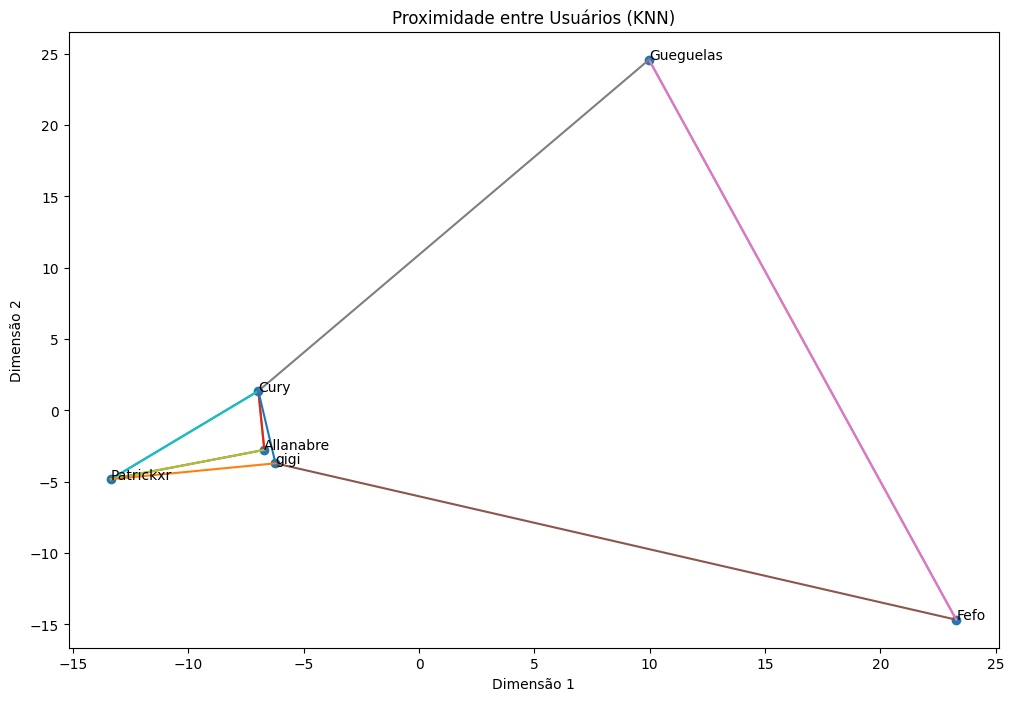

In [25]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors



pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)


distancias, indices = knn.kneighbors(X_scaled, n_neighbors=3)

# =========================
# 4. PLOT
# =========================
plt.figure(figsize=(12, 8))

# pontos
plt.scatter(X_2d[:,0], X_2d[:,1])

# nomes dos usuários
for i, user in enumerate(pivot.index):
    plt.text(X_2d[i,0], X_2d[i,1], user)

# linhas conectando vizinhos mais próximos
for i in range(len(pivot)):
    for j in indices[i][1:]:  # ignora ele mesmo
        plt.plot(
            [X_2d[i,0], X_2d[j,0]],
            [X_2d[i,1], X_2d[j,1]]
        )

plt.title("Proximidade entre Usuários (KNN)")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.show()

## Conclusão

- Usuários foram representados por seus perfis de preferência por gênero
- O KNN permite identificar usuários similares
- A visualização em PCA mostra possíveis clusters de comportamento
- Essa abordagem pode ser utilizada para recomendações baseadas em usuários semelhantes
